This notebook analyses the data previously published by [Best et al. (2015)](http://dx.doi.org/10.1016/j.ccell.2015.09.018) using a RF model.

This notebook was written by Mauriz Lichtenstein

# 1. Import packages

In [ ]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gzip
import shutil

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

# 2. Load data

In [ ]:
data = pd.read_csv(f'data/GSE68086_TEP_data_matrix.txt', sep='\t', index_col=0)

# Table S1. Patient Characteristics
patient_training = pd.read_excel('data/1-s2.0-S1535610815003499-mmc2.xlsx', sheet_name='Training', header=3).iloc[:-11]
patient_validation = pd.read_excel('data/1-s2.0-S1535610815003499-mmc2.xlsx', sheet_name='Validation', header=3).iloc[:-11]

# patient_training = patient_training.

/opt/homebrew/Caskroom/miniconda/base/envs/mlails/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/Caskroom/miniconda/base/envs/mlails/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
patient_training

,Sample,Patient type,Gender,Age,Mutation,Metastasis,Organ of metastasis,Cancer treatment
0,HC-01,Healthy Donor (HD),M,53,-,-,-,-
1,HC-04,Healthy Donor (HD),F,64,-,-,-,-
2,HC-05,Healthy Donor (HD),F,64,-,-,-,-
3,HC-06,Healthy Donor (HD),M,41,-,-,-,-
4,HC-07,Healthy Donor (HD),M,49,-,-,-,-
...,...,...,...,...,...,...,...,...
170,Chol-379,Hepatobiliary carcinoma (HBC),F,75,KRAS WT,Y,"Lung, adrenal",CT
171,Chol-410,Hepatobiliary carcinoma (HBC),M,69,KRAS mut,Y,"Liver, pancreas","Surgery, CT"
172,Liver-274,Hepatobiliary carcinoma (HBC),M,48,KRAS WT,N,-,Surgery
173,Liver-366,Hepatobiliary carcinoma (HBC),M,64,KRAS WT,Y,Liver,CT


In [4]:
# Prepare Labels
patient_training['label'] = patient_training['Patient type'].str.split(r'\(').str[1].str.split(r'\)').str[0]
patient_validation['label'] = patient_validation['Patient type'].str.split(r'\(').str[1].str.split(r'\)').str[0]

labels = {sample: label for sample, label in zip(patient_training['Sample'], patient_training['label'])}
labels.update({sample: label for sample, label in zip(patient_validation['Sample'], patient_validation['label'])})


labels = data.columns.to_series().map(labels)
data_T = data.T


# 3. Label data

In [5]:
# Prepare Labels using sample name rules
def map_label(sample):
    if 'HD' in sample:
        return 'HD'
    elif 'NSCLC' in sample or 'Lung' in sample:
        return 'NSCLC'
    elif 'CRC' in sample:
        return 'CRC'
    elif 'Pancr' in sample:
        return 'PAAD'
    elif 'GBM' in sample:
        return 'GBM'
    elif 'Breast' in sample or 'BrCa' in sample:
        return 'BrCa'
    elif 'HBC' in sample or 'Chol' in sample or 'Liver' in sample:
        return 'HBC'
    else:
        return 'Other'

data_T = data.T

data_T['label'] = data_T.index.map(map_label)
data_T['label_binary'] = np.where(data_T['label'] == 'HD', 'Healthy', 'Cancer')

# 4. Binary Classification

In [6]:
# Train/Test Split
X_bin = data_T.drop(columns=['label_binary', 'label'])
y_bin = data_T['label_binary']
X_train_bin, X_val_bin, y_train_bin, y_val_bin = train_test_split(X_bin, y_bin, stratify=y_bin, test_size=0.3, random_state=42)

In [17]:
72+14

86

In [14]:
y_train_bin.value_counts(), y_val_bin.value_counts()

(label_binary
 Cancer     168
 Healthy     31
 Name: count, dtype: int64,
 label_binary
 Cancer     72
 Healthy    14
 Name: count, dtype: int64)

Train Accuracy: 1.00, AUC: 1.00
Validation Accuracy: 0.93, AUC: 0.92


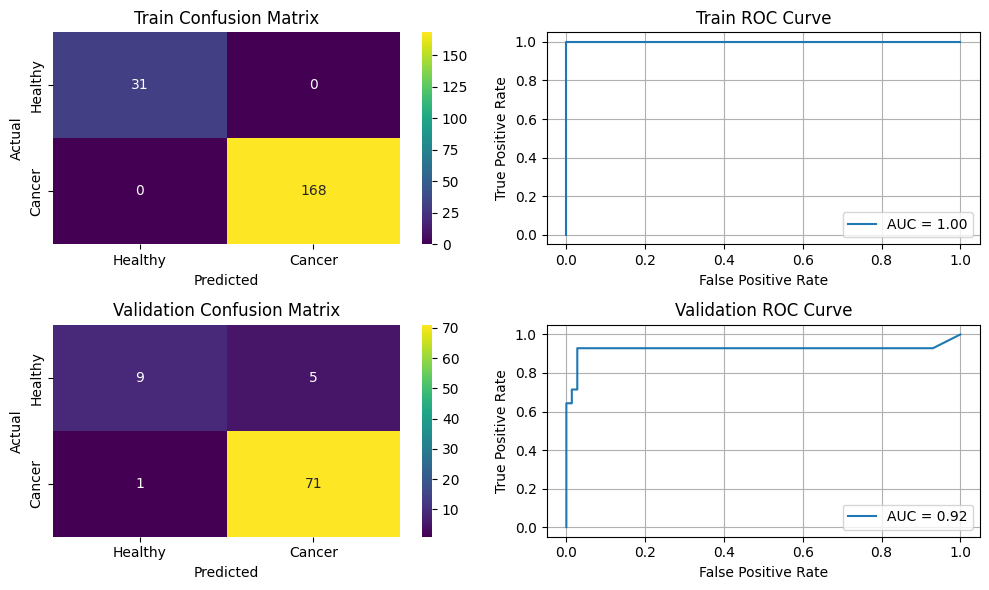

In [18]:
rf_bin = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bin.fit(X_train_bin, y_train_bin)

fig, axs = plt.subplots(2, 2, figsize=(10, 6))

# Predict and Evaluate
for i,(X, y, name) in enumerate([(X_train_bin, y_train_bin, 'Train'), (X_val_bin, y_val_bin, 'Validation')]):
    y_pred = rf_bin.predict(X)
    y_prob = rf_bin.predict_proba(X)[:, 1] if 'Healthy' in rf_bin.classes_ else rf_bin.predict_proba(X)[:, 0]
    cm = confusion_matrix(y, y_pred, labels=['Healthy', 'Cancer'])
    acc = accuracy_score(y, y_pred)
    fpr, tpr, _ = roc_curve((y == 'Healthy').astype(int), y_prob)
    roc_auc = auc(fpr, tpr)
    print(f"{name} Accuracy: {acc:.2f}, AUC: {roc_auc:.2f}")

    # Plot Confusion Matrix and ROC Curve
    axs[i, 0].set_title(f'{name} Confusion Matrix')
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', ax=axs[i, 0], xticklabels=['Healthy', 'Cancer'], yticklabels=['Healthy', 'Cancer'])
    axs[i, 0].set_xlabel('Predicted')
    axs[i, 0].set_ylabel('Actual')

    axs[i, 1].set_title(f'{name} ROC Curve')
    axs[i, 1].plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    axs[i, 1].set_xlabel('False Positive Rate')
    axs[i, 1].set_ylabel('True Positive Rate')
    axs[i, 1].legend()
    axs[i, 1].grid()

plt.tight_layout()
plt.show()


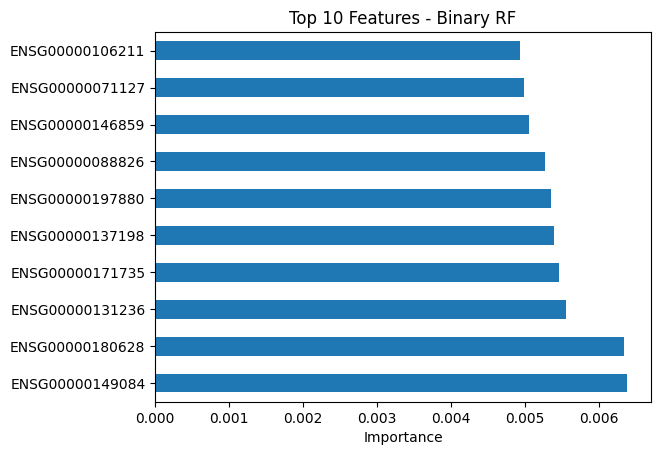

In [8]:
# Feature Importance (Binary)
importances_bin = pd.Series(rf_bin.feature_importances_, index=X_bin.columns)
important_bin_features = importances_bin.nlargest(10)
important_bin_features.plot(kind='barh', title='Top 10 Features - Binary RF')
plt.xlabel('Importance')
plt.show()

# 5. Multiclass

In [15]:
classes = [sample for sample in data_T['label'].unique() if sample != 'Other']

multi_T = data_T[data_T['label'].isin(classes)]

min_count_multi = multi_T['label'].value_counts().min()
balanced_multi = multi_T.groupby('label').sample(n=min_count_multi, random_state=42)

# Train/Test Split
X_multi = balanced_multi.drop(columns=['label_binary', 'label'])
y_multi = balanced_multi['label']
X_train_multi, X_val_multi, y_train_multi, y_val_multi = train_test_split(X_multi, y_multi, stratify=y_multi, test_size=0.3, random_state=42)

Train Accuracy (Multiclass): 1.00
Validation Accuracy (Multiclass): 0.31


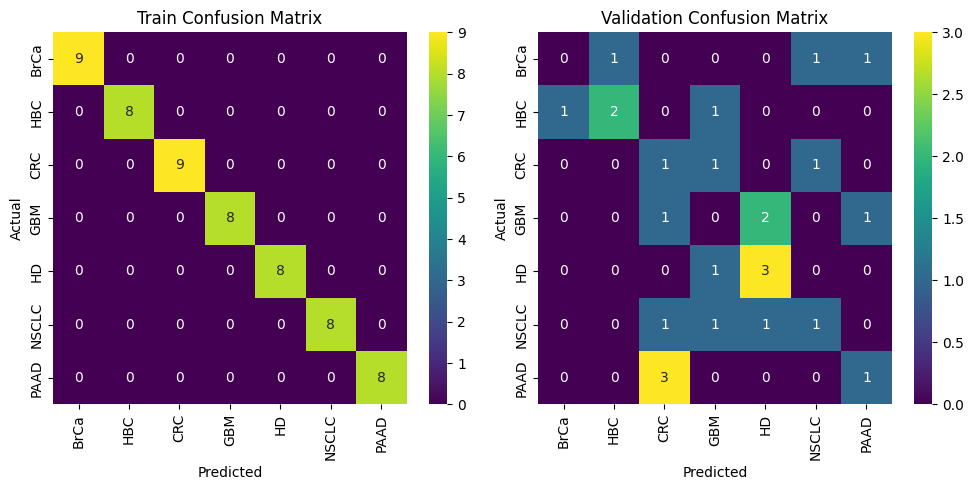

In [16]:
# Train Multi-class RF Model
rf_multi = RandomForestClassifier(n_estimators=100, random_state=42)
rf_multi.fit(X_train_multi, y_train_multi)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Predict and Evaluate
for i, (X, y, name) in enumerate([(X_train_multi, y_train_multi, 'Train'), (X_val_multi, y_val_multi, 'Validation')]):
    y_pred = rf_multi.predict(X)
    acc = accuracy_score(y, y_pred)
    cm = confusion_matrix(y, y_pred, labels=classes)
    print(f"{name} Accuracy (Multiclass): {acc:.2f}")
    axs[i].set_title(f'{name} Confusion Matrix')
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', ax=axs[i], xticklabels=classes, yticklabels=classes)
    axs[i].set_xlabel('Predicted')
    axs[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

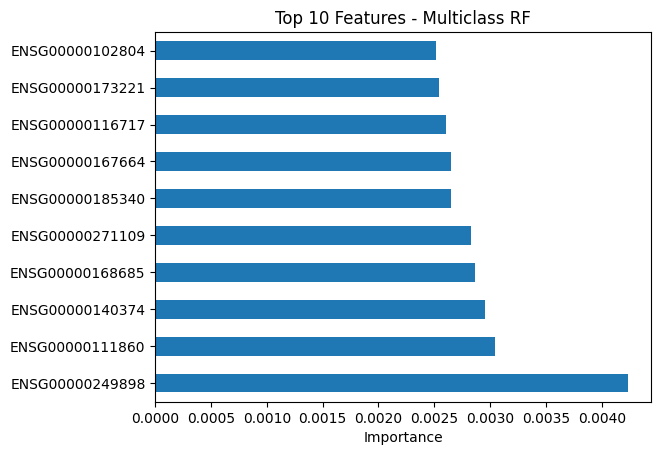

In [ ]:
# Feature Importance (Multiclass)
importances_multi = pd.Series(rf_multi.feature_importances_, index=X_multi.columns)
important_multi_features = importances_multi.nlargest(10)
important_multi_features.plot(kind='barh', title='Top 10 Features - Multiclass RF')
plt.xlabel('Importance')
plt.show()
